In [1]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import itertools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
#from google.colab import drive
from sklearn.metrics import mean_squared_error, r2_score

# Importing Training Data

file_path = "https://docs.google.com/spreadsheets/d/1p46W8CXh68qWmPxK5F6aYHqMBjzzMHER/export?format=xlsx"

df = pd.read_excel(file_path)
X = df.iloc[:,0:5]
y = df.iloc[:,5]

In [2]:
print(X.shape, y.shape, type(X), type(y), df.shape)
print(df.iloc[:,0:5].head())
(df.iloc[:,5].head())

(7776, 5) (7776,) <class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'> (7776, 6)
    T_rxn  SbyC   Pt  CatalystAmt    U
0  873.15   1.0  7.0          500  1.0
1  873.15   1.0  7.0          500  2.8
2  873.15   1.0  7.0          500  4.6
3  873.15   1.0  7.0          500  6.4
4  873.15   1.0  7.0          500  8.2


0    0.169425
1    0.169425
2    0.169417
3    0.169290
4    0.168811
Name: Conversion, dtype: float64

In [3]:
# Analyse the traiining dataa
print(df.describe())
#df_filtered = df[(df['Pt'] == 2) & (df['T_rxn'] == 973.15) & (df['T_in'] == 773.15) & (df['SbyC'] == 2)]
#df_filtered

             T_rxn         SbyC           Pt  CatalystAmt            U  \
count  7776.000000  7776.000000  7776.000000  7776.000000  7776.000000   
mean    973.150000     2.000000    13.500000   750.000000     5.500000   
std      68.317398     0.683174     4.440631   170.793495     3.074283   
min     873.150000     1.000000     7.000000   500.000000     1.000000   
25%     913.150000     1.400000     9.600000   600.000000     2.800000   
50%     973.150000     2.000000    13.500000   750.000000     5.500000   
75%    1033.150000     2.600000    17.400000   900.000000     8.200000   
max    1073.150000     3.000000    20.000000  1000.000000    10.000000   

        Conversion  
count  7776.000000  
mean      0.329014  
std       0.135239  
min       0.082733  
25%       0.222007  
50%       0.314775  
75%       0.426439  
max       0.710329  


## Train test split & Scaling

In [9]:
# Split into training and testing sets - Random state set for Reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Analyse the traiining dataa
print(df.describe())


             T_rxn         SbyC           Pt  CatalystAmt            U  \
count  7776.000000  7776.000000  7776.000000  7776.000000  7776.000000   
mean    973.150000     2.000000    13.500000   750.000000     5.500000   
std      68.317398     0.683174     4.440631   170.793495     3.074283   
min     873.150000     1.000000     7.000000   500.000000     1.000000   
25%     913.150000     1.400000     9.600000   600.000000     2.800000   
50%     973.150000     2.000000    13.500000   750.000000     5.500000   
75%    1033.150000     2.600000    17.400000   900.000000     8.200000   
max    1073.150000     3.000000    20.000000  1000.000000    10.000000   

        Conversion  
count  7776.000000  
mean      0.329014  
std       0.135239  
min       0.082733  
25%       0.222007  
50%       0.314775  
75%       0.426439  
max       0.710329  


In [10]:

x_scaler = StandardScaler()
y_scaler = StandardScaler()

# Fit the scaler on the training data
x_scaler.fit(X_train)
y_train = y_train.values.reshape(-1, 1)
y_scaler.fit(y_train)

# Transform the training data
X_train_scaled = x_scaler.transform(X_train)
y_train_scaled = y_scaler.transform(y_train)

# Transform the test data using the same mean and std from the training data
X_test_scaled = x_scaler.transform(X_test)
y_test = y_test.values.reshape(-1, 1)
y_test_scaled = y_scaler.transform(y_test)

# Convert scaled data to PyTorch tensors
X_train_scaled_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_scaled_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_scaled_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_scaled_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)



## Neural Network defined

Epoch [500/7000], Training Loss: 1.0097, Test Loss: 1.0034
Epoch [1000/7000], Training Loss: 0.9782, Test Loss: 0.9694
Epoch [1500/7000], Training Loss: 0.7709, Test Loss: 0.7562
Epoch [2000/7000], Training Loss: 0.4138, Test Loss: 0.3893
Epoch [2500/7000], Training Loss: 0.2621, Test Loss: 0.2444
Epoch [3000/7000], Training Loss: 0.0381, Test Loss: 0.0367
Epoch [3500/7000], Training Loss: 0.0120, Test Loss: 0.0125
Epoch [4000/7000], Training Loss: 0.0076, Test Loss: 0.0082
Epoch [4500/7000], Training Loss: 0.0056, Test Loss: 0.0062
Epoch [5000/7000], Training Loss: 0.0045, Test Loss: 0.0050
Epoch [5500/7000], Training Loss: 0.0037, Test Loss: 0.0041
Epoch [6000/7000], Training Loss: 0.0031, Test Loss: 0.0034
Epoch [6500/7000], Training Loss: 0.0026, Test Loss: 0.0028
Epoch [7000/7000], Training Loss: 0.0022, Test Loss: 0.0024
Training R² Score: 0.9978
Test R² Score: 0.9976


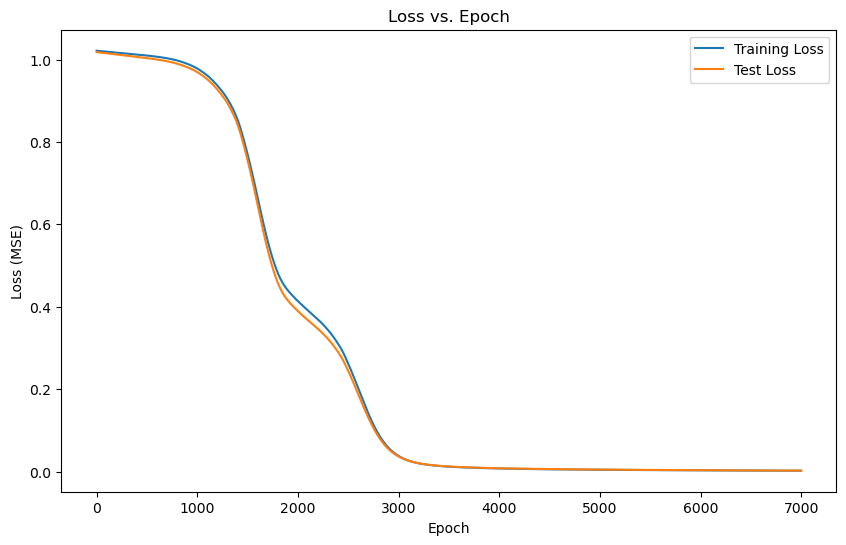

In [11]:


# Define the neural network model with multiple hidden layers
class SMRNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SMRNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)  # Additional hidden layer
        self.fc4 = nn.Linear(hidden_size, hidden_size)  # Another additional hidden layer
        self.fc5 = nn.Linear(hidden_size, hidden_size)  # Another additional hidden layer
        self.fc6 = nn.Linear(hidden_size, hidden_size)  # Another additional hidden layer
        self.fc7 = nn.Linear(hidden_size, hidden_size)  # Another additional hidden layer
        self.fc8 = nn.Linear(hidden_size, hidden_size)  # Another additional hidden layer
        self.fc9 = nn.Linear(hidden_size, hidden_size)  # Another additional hidden layer

        self.fc10 = nn.Linear(hidden_size, output_size)  # Output layer

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        x = self.relu(self.fc5(x))
        x = self.relu(self.fc6(x))
        x = self.relu(self.fc7(x))
        x = self.relu(self.fc8(x))
        x = self.relu(self.fc9(x))
        x = self.fc10(x)
        return x

# Sample Data: 5 input features (T_rxn,  S/C , Pt, CatalystAmt, U), 1 output (conversion)
data = X_train_scaled_tensor
target = y_train_scaled_tensor

# Initialize the network
model = SMRNet(input_size=5, hidden_size=50, output_size=1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)
criterion = nn.MSELoss()

# Initialize lists to store loss values
train_losses = []
test_losses = []

# Training the model
epochs = 7000
for epoch in range(epochs):
    model.train()

    # Forward pass and calculate training loss
    outputs = model(X_train_scaled_tensor)
    train_loss = criterion(outputs, y_train_scaled_tensor)
    train_losses.append(train_loss.item())

    # Backward pass and optimization
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # Evaluate the model on the test set every epoch and store test loss
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_scaled_tensor)
        test_loss = criterion(test_outputs, y_test_scaled_tensor)
        test_losses.append(test_loss.item())

    if (epoch + 1) % 500 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Training Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

# Convert outputs to numpy arrays for R² calculation
with torch.no_grad():
    train_pred = model(X_train_scaled_tensor).numpy()
    train_true = y_train_scaled_tensor.numpy()
    test_pred = model(X_test_scaled_tensor).numpy()
    test_true = y_test_scaled_tensor.numpy()

# Calculate R² scores
train_r2 = r2_score(train_true, train_pred)
test_r2 = r2_score(test_true, test_pred)

print(f'Training R² Score: {train_r2:.4f}')
print(f'Test R² Score: {test_r2:.4f}')

# Plotting loss curves
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_losses, label='Training Loss')
plt.plot(range(epochs), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Loss vs. Epoch')
plt.legend()
plt.show()



## Grid Search Optimization

In [12]:


# **Grid Search Optimization** #

# Define the ranges for grid search
temperature_range = np.linspace(600, 800, 10) + 273.15  # e.g., 10 values between 600 and 800
pressure_range = np.linspace(7, 20, 10)         # e.g., 10 values between 7 and 20
sc_ratio_range = np.linspace(1, 3, 10)          # e.g., 10 values between 1 and 3
amtCat_range = np.linspace(500, 1000, 10)       # e.g., 10 values between 500 and 1000
U_range = np.linspace(0.5, 5, 10)               # e.g., 10 values between 0.5 and 5

# Create the meshgrid for all combinations
T, SC, P, Amt, U = np.meshgrid(temperature_range, sc_ratio_range, pressure_range, amtCat_range, U_range)

# Reshape the grid into a single variable (N x 5 matrix, where N is the total number of combinations)
X_grid = np.vstack([T.ravel(), SC.ravel(), P.ravel(), Amt.ravel(), U.ravel()]).T

# Check the shape of X_grid
print(X_grid.shape)  # Should be (100000, 5) for 10x10x10x10x10 combinations



(100000, 5)


In [13]:

# Transform the training data
X_grid_scaled = x_scaler.transform(X_grid)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [14]:

# Initialize variable to store best result
best_conversion = -float('inf')
best_conditions = None

# Iterate over all combinations in the grid
for condition in X_grid_scaled:
    condition_tensor = torch.tensor(condition, dtype=torch.float32).unsqueeze(0)  # Convert each row to tensor and add batch dimension

    # Predict conversion for the current condition
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        predicted_conversion = model(condition_tensor).item()  # Get scalar prediction

    # Check if this is the best conversion
    if predicted_conversion > best_conversion:
        best_conversion = predicted_conversion
        best_conditions = condition  # Store the scaled condition

# Output the best result (inverse transform to get back to original scale)

# best_conditions_original = x_scaler_grid.inverse_transform([best_conditions])
best_conditions_original = x_scaler.inverse_transform([best_conditions])
best_conversion_original = y_scaler.inverse_transform([[best_conversion]])
print(f'Best conditions: Temperature: {best_conditions_original[0][0]:.2f} K, S/C Ratio: {best_conditions_original[0][1]:.2f}, Pressure: {best_conditions_original[0][2]:.2f} bar, Amt Catalyst: {best_conditions_original[0][3]:.2f}, Velocity: {best_conditions_original[0][4]:.2f}')
print(f'Predicted conversion: {best_conversion_original[0][0]:.4f}')


Best conditions: Temperature: 1073.15 K, S/C Ratio: 3.00, Pressure: 7.00 bar, Amt Catalyst: 666.67, Velocity: 4.50
Predicted conversion: 0.7079


**From Numerical solution :** Converion = 71.03% , which is very close to 71.37%

In [15]:
torch.save(model.state_dict(), "smr_model.pt")

In [16]:
import joblib
joblib.dump(x_scaler, "x_scaler.pkl")
joblib.dump(y_scaler, "y_scaler.pkl")

['y_scaler.pkl']

In [17]:
model2 = SMRNet(input_size=5, hidden_size=50, output_size=1)
model2.load_state_dict(torch.load("smr_model.pt"))
model2.eval()

x_sc = joblib.load("x_scaler.pkl")
y_sc = joblib.load("y_scaler.pkl")
print("Files load correctly — ready to deploy")

Files load correctly — ready to deploy
